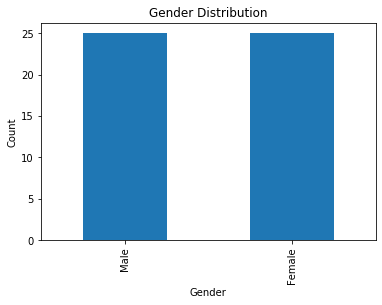

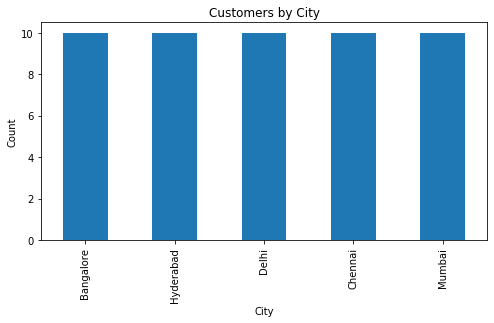

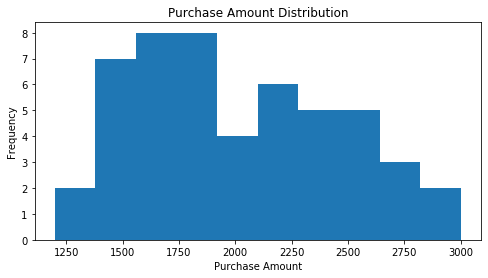

In [1]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("customer_data_cleaned.csv")

# Gender Distribution
plt.figure(figsize=(6,4))
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# City Distribution
plt.figure(figsize=(8,4))
df['City'].value_counts().plot(kind='bar')
plt.title("Customers by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

# Purchase Amount Distribution
plt.figure(figsize=(8,4))
plt.hist(df['PurchaseAmount'], bins=10)
plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

In [2]:
import pandas as pd
import sqlite3

# Load the cleaned dataset
df = pd.read_csv("customer_data_cleaned.csv")

# Create an in-memory SQLite database
conn = sqlite3.connect(':memory:')

# Save dataframe as SQL table named 'customers'
df.to_sql('customers', conn, index=False, if_exists='replace')

print("Table 'customers' created successfully!")

Table 'customers' created successfully!


In [3]:
#SQL Queries
query = """
SELECT Name, PurchaseAmount
FROM customers
ORDER BY PurchaseAmount DESC
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,Name,PurchaseAmount
0,Rajesh,3000.0
1,Mahesh,2900.0
2,Prakash,2800.0
3,Nikhil,2700.0
4,Murali,2700.0


In [4]:
query = """
SELECT ROUND(AVG(PurchaseAmount), 2) AS AveragePurchase
FROM customers;
"""

pd.read_sql_query(query, conn)

,AveragePurchase
0,2004.08


In [5]:
query = """
SELECT City, COUNT(*) AS TotalCustomers
FROM customers
GROUP BY City;
"""

pd.read_sql_query(query, conn)

,City,TotalCustomers
0,Bangalore,10
1,Chennai,10
2,Delhi,10
3,Hyderabad,10
4,Mumbai,10


In [6]:
query = """
SELECT Gender,
ROUND(AVG(PurchaseAmount), 2) AS AveragePurchase
FROM customers
GROUP BY Gender;
"""

pd.read_sql_query(query, conn)

,Gender,AveragePurchase
0,Female,1676.00
1,Male,2332.16


In [7]:
query = """
SELECT Name, PurchaseAmount
FROM customers
WHERE PurchaseAmount >
(
    SELECT AVG(PurchaseAmount)
    FROM customers
)
ORDER BY PurchaseAmount DESC;
"""

pd.read_sql_query(query, conn)

,Name,PurchaseAmount
0,Rajesh,3000.0
1,Mahesh,2900.0
2,Prakash,2800.0
3,Nikhil,2700.0
4,Murali,2700.0
5,Varun,2600.0
6,Chandra,2600.0
7,Karan,2500.0
8,Santosh,2500.0
9,Hari,2500.0


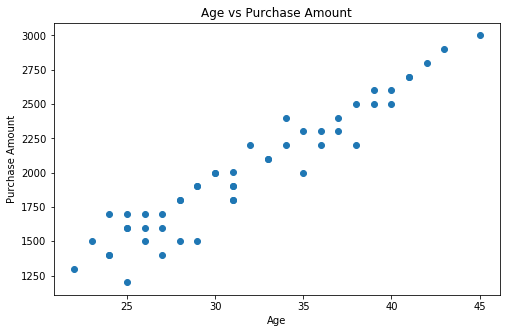

In [8]:
#Scatter Plot
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("customer_data_cleaned.csv")

plt.figure(figsize=(8,5))
plt.scatter(df['Age'], df['PurchaseAmount'])

plt.title('Age vs Purchase Amount')
plt.xlabel('Age')
plt.ylabel('Purchase Amount')

plt.show()

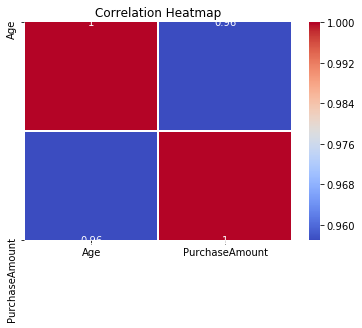

In [9]:
#Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

correlation = df[['Age', 'PurchaseAmount']].corr()

plt.figure(figsize=(6,4))

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title('Correlation Heatmap')

plt.show()

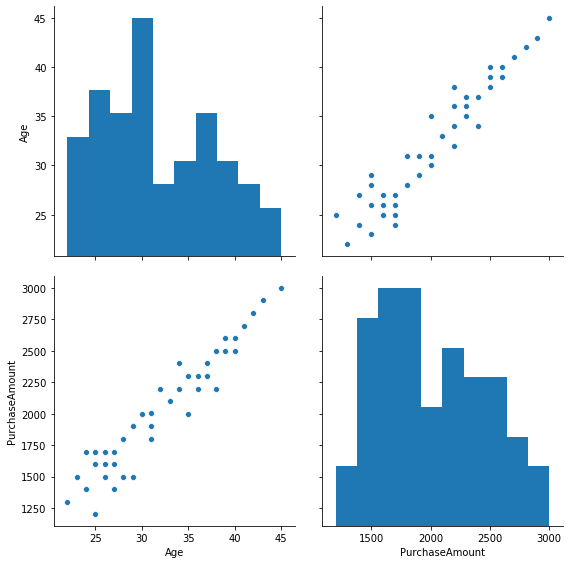

In [10]:
#Pair Plot
import seaborn as sns

sns.pairplot(
    df[['Age', 'PurchaseAmount']],
    height=4
)

plt.show()

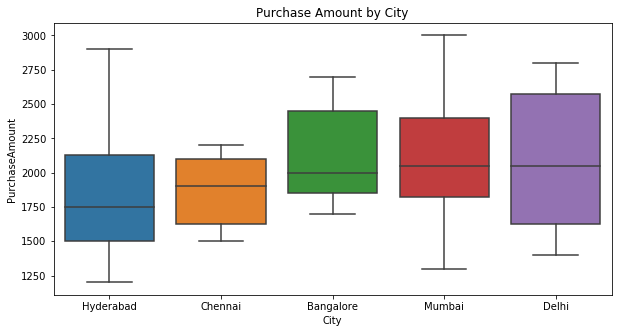

In [11]:
#Box Plot
plt.figure(figsize=(10,5))

sns.boxplot(
    x='City',
    y='PurchaseAmount',
    data=df
)

plt.title('Purchase Amount by City')

plt.show()